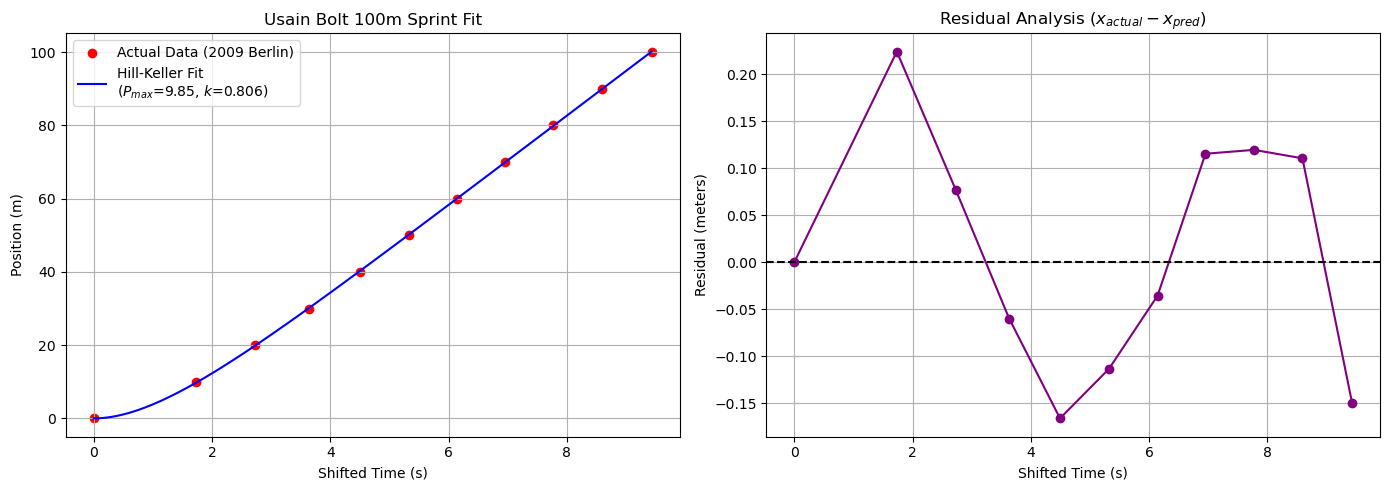

Task 2
Pmax Best-Fit = 9.85 m/s^2  | Std. Error: 0.086 | 95% CI: [9.68, 10.02]
k Best-Fit    = 0.806 1/s     | Std. Error: 0.0088 | 95% CI: [0.788, 0.82]
Implied top speed Pmax/k = 12.2 m/s

Task 3
Distance (m)   Predicted Time      Actual World Record
100            9.57 s              9.58 s (Usain Bolt, 2009)
200            17.75 s             19.19 s (Usain Bolt, 2009)
400            34.11 s             43.03 s (Wayde van Niekerk, 2016)
800            1:06.84             1:40.91 (David Rudisha, 2012)
1500           2:04.11             3:26.00 (Hicham El Guerrouj, 1998)
5000           6:50.45             12:35.36 (Joshua Cheptegei, 2020)
10000          13:39.51            26:11.00 (Joshua Cheptegei, 2020)


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, root_scalar

#Task 2

df = pd.read_csv('usain_bolt.csv')
df = df.rename(columns={'Time2009': 'time', 'Position': 'position'})
t_reaction = df.iloc[0]['time']
df['t_shifted'] = df['time'] - t_reaction

t_all = df['t_shifted'].values
x_all = df['position'].values
t_fit = t_all[1:]
x_fit = x_all[1:]

def keller_model(t, P_max, k):
    return (P_max / (k**2)) * (k * t + np.exp(-k * t) - 1)

popt, pcov = curve_fit(keller_model, t_fit, x_fit, p0=[10, 1])
P_max_opt, k_opt = popt

perr = np.sqrt(np.diag(pcov))

P_max_ci = [P_max_opt - 1.96 * perr[0], P_max_opt + 1.96 * perr[0]]
k_ci = [k_opt - 1.96 * perr[1], k_opt + 1.96 * perr[1]]

t_plot = np.linspace(0, t_all[-1], 200)
x_plot = keller_model(t_plot, P_max_opt, k_opt)
x_pred_all = keller_model(t_all, P_max_opt, k_opt)
residuals = x_all - x_pred_all

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(t_all, x_all, color='red', label='Actual Data (2009 Berlin)')
ax1.plot(t_plot, x_plot, label=f'Hill-Keller Fit\n($P_{{max}}$={P_max_opt:.2f}, $k$={k_opt:.3f})', color='blue')
ax1.set_xlabel('Shifted Time (s)')
ax1.set_ylabel('Position (m)')
ax1.set_title("Usain Bolt 100m Sprint Fit")
ax1.legend()
ax1.grid(True)
ax2.plot(t_all, residuals, 'o-', color='purple')
ax2.axhline(0, color='black', linestyle='--')
ax2.set_xlabel('Shifted Time (s)')
ax2.set_ylabel('Residual (meters)')
ax2.set_title("Residual Analysis ($x_{actual} - x_{pred}$)")
ax2.grid(True)

plt.tight_layout()
plt.show()

#Task 3

def time_for_distance(d, P_max, k):
    target_func = lambda t: keller_model(t, P_max, k) - d
    sol = root_scalar(target_func, bracket=[0, 5000])
    return sol.root + t_reaction 

distances = [100, 200, 400, 800, 1500, 5000, 10000]
world_records = {
    100: "9.58 s (Usain Bolt, 2009)",
    200: "19.19 s (Usain Bolt, 2009)",
    400: "43.03 s (Wayde van Niekerk, 2016)",
    800: "1:40.91 (David Rudisha, 2012)",
    1500: "3:26.00 (Hicham El Guerrouj, 1998)",
    5000: "12:35.36 (Joshua Cheptegei, 2020)",
    10000: "26:11.00 (Joshua Cheptegei, 2020)"
}

print("Task 2")
print(f"Pmax Best-Fit = {P_max_opt:.2f} m/s^2  | Std. Error: {perr[0]:.3f} | 95% CI: [{P_max_ci[0]:.2f}, {P_max_ci[1]:.2f}]")
print(f"k Best-Fit    = {k_opt:.3f} 1/s     | Std. Error: {perr[1]:.4f} | 95% CI: [{k_ci[0]:.3f}, {k_ci[1]:.2f}]")
print(f"Implied top speed Pmax/k = {P_max_opt/k_opt:.1f} m/s\n")

print("Task 3")
print(f"{'Distance (m)':<15}{'Predicted Time':<20}{'Actual World Record'}")
for d in distances:
    t_pred = time_for_distance(d, P_max_opt, k_opt)
    
    if t_pred >= 60:
        mins = int(t_pred // 60)
        secs = t_pred % 60
        t_str = f"{mins}:{secs:05.2f}"
    else:
        t_str = f"{t_pred:.2f} s"
        
    print(f"{d:<15}{t_str:<20}{world_records[d]}")